In [1]:
import pandas as pd
import matplotlib.pyplot as plt

master_df = pd.read_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\master_dataset.csv"
)

master_df["Month"] = pd.to_datetime(master_df["Month"])

master_df.head()

,Month,Occupation,Demand,SOC_Code,Median_Salary
0,2023-01-01,Programmers and software development professio...,25269.0,2134.0,52500
1,2023-02-01,Programmers and software development professio...,25118.0,2134.0,55000
2,2023-03-01,Programmers and software development professio...,21905.0,2134.0,55000
3,2023-04-01,Programmers and software development professio...,15409.0,2134.0,55000
4,2023-05-01,Programmers and software development professio...,17787.0,2134.0,55000


In [ ]:
summary = master_df.describe()

summary

,Month,Demand,SOC_Code,Median_Salary
count,145,145.000000,145.000000,145.000000
mean,2024-03-01 13:14:28.965517,3769.565517,2675.800000,46980.000000
min,2023-01-01 00:00:00,656.000000,2134.000000,30000.000000
25%,2023-08-01 00:00:00,1409.000000,2135.000000,40000.000000
50%,2024-03-01 00:00:00,1760.000000,2433.000000,52500.000000
75%,2024-10-01 00:00:00,3073.000000,3133.000000,55000.000000
max,2025-05-01 00:00:00,25269.000000,3544.000000,60000.000000
std,NaN,4678.190440,569.022293,9633.669256


In [3]:
summary.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\summary_statistics_master.csv"
)

In [4]:
correlation = master_df[["Demand", "Median_Salary"]].corr()

print(correlation)

                 Demand  Median_Salary
Demand         1.000000       0.320297
Median_Salary  0.320297       1.000000


In [ ]:
correlation.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\demand_salary_correlation.csv"
)

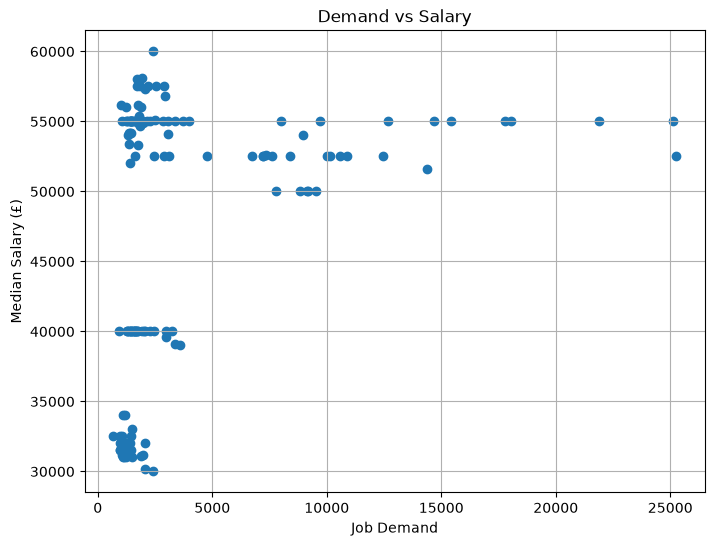

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    master_df["Demand"],
    master_df["Median_Salary"]
)

plt.xlabel("Job Demand")

plt.ylabel("Median Salary (£)")

plt.title("Demand vs Salary")

plt.grid(True)

plt.show()

In [7]:
import os

os.makedirs(
    r"D:\MScProjects\labour-market-intelligence\results",
    exist_ok=True
)

plt.savefig(
    r"D:\MScProjects\labour-market-intelligence\results\demand_vs_salary.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [8]:
occupation_summary = master_df.groupby("Occupation").agg({
    "Demand": ["mean", "max", "min"],
    "Median_Salary": ["mean", "max", "min"]
})

occupation_summary

Demand           \
                                                            mean      max   
Occupation                                                                  
Actuaries, economists and statisticians              1988.379310   3993.0   
Cyber security professionals                         1924.827586   3712.0   
Data analysts                                        1903.413793   3606.0   
Database administrators and web content technic...   1317.137931   2397.0   
Programmers and software development professionals  11714.068966  25269.0   

                                                           Median_Salary  \
                                                       min          mean   
Occupation                                                                 
Actuaries, economists and statisticians             1057.0  54731.034483   
Cyber security professionals                        1032.0  55662.068966   
Data analysts                                        913.0  39920.689655   
Database administrators and web content technic...   656.0  31717.241379   
Programmers and software development professionals  4754.0  52868.965517   

                                                                  
                                                      max    min  
Occupation                                                        
Actuaries, economists and statisticians             57500  52000  
Cyber security professionals                        60000  52500  
Data analysts                                       40000  39000  
Database administrators and web content technic...  34000  30000  
Programmers and software development professionals  55000  50000

In [9]:
occupation_summary.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\occupation_summary.csv"
)